## Initialize environment, build MPI applications, and import dependencies

In [1]:
%%capture
! make clean
! make

In [2]:
import dragon
import multiprocessing as mp

import copy
import cv2
import io
import socket
import sys
import time
import os
import math
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img
from itertools import count
from model import Net, make_features, infer, train

from dragon.native.process import Process, ProcessTemplate, Popen
from dragon.native.process_group import ProcessGroup
from dragon.infrastructure.connection import Connection
from dragon.native.machine import System
import dragon.workflows.runtime as runtime
from dragon.infrastructure.facts import PMIBackend

from hpc_ai_workflow import parse_results, compute_cheap_approx, generate_data, plot_model, cleanup, parallel_exec_infer_approx

# we want to use some dragon multiprocessing objects later so we set the start method to Dragon once at the beginning
mp.set_start_method("dragon")

## HPC-AI Converged Workflow - Training a surrogate model with AI Cloud Serverless
### Train a model to compute sin(x)

## Check what compute resources we currently have available on our local cluster

In [3]:
# System is a convenient abstraction of the available resources in my allocation
my_alloc = System()
print(f"# nodes available to me: {my_alloc.nnodes}", flush=True)
try:
    available_resources.append((time.time(), int(my_alloc.nnodes)))
except:
    available_resources = []
    available_resources.append((time.time(), int(my_alloc.nnodes)))

# nodes available to me: 1


## Initialize model

In [4]:
# define model
model = Net()
# define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# load a reasonable pretrained model
path = "model_pretrained_poly.pt"
checkpoint = torch.load(path)
model.load_state_dict(checkpoint["model_state_dict"])

model.fc.weight.data+=torch.randn(model.fc.weight.size())*.1


## Define a point in parameter space to compare our model and approximation

In [5]:
# define a point you want to compare at
input_float = 2.5
x = torch.tensor([input_float])

## Run model inference and parallel approximation application simultaneously

In [6]:
parallel_exec_infer_approx(model, x)

model: 16.669010162353516


## Visualize the model compared to sin(x)

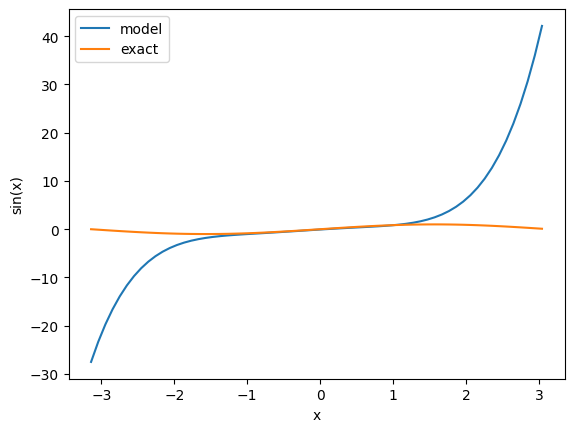

In [7]:
plot_model(model)

original_model = copy.deepcopy(model.fc.weight)

## But we don't have enough resources on this cluster. Let's use a proxy environment to train at-scale!

In [8]:
system = 'portage'

remote_cwd='/lus/scratch/wahlc/dragon/dev/proxy-dev/examples/workflows/proxy'
runtime_sdesc = runtime.lookup(system, 'my-runtime', 30, publish_dir=remote_cwd)
proxy = runtime.attach(runtime_sdesc, remote_cwd=remote_cwd)

Connecting to OOB transport agents on port 9575 with 16.143.10.54 and 10.150.0.204
Starting OOB transport agents on port 9575


## What resources do we have available now that we connected to our remote runtime?

In [18]:
try:
    available_resources.append((time.time(), int(my_alloc.nnodes)))
except:
    available_resources = []
    available_resources.append((time.time(), int(my_alloc.nnodes)))
proxy.enable()

my_alloc = System()
print(f"# nodes available to me: {my_alloc.nnodes}", flush=True)
available_resources.append((time.time(), int(my_alloc.nnodes)))

# nodes available to me: 2


## Generate some new training data for our surrogate model

In [19]:
# num mpi ranks to launch on each node for data generation
ranks_per_node = 8
# interval that we train on
data_interval = [-math.pi, math.pi]
# data samples generated by each rank.
# total num samples in training set is: nnodes * ranks_per_node * data_samples_per_rank
data_samples_per_rank = 32

# generate data
data, target = generate_data( my_alloc.nnodes * ranks_per_node, data_samples_per_rank, data_interval, 0, proxy)

## Now train the model

In [20]:
loss = train(model, optimizer, data, target)

## And now plot the new model compared to sin(x) just like before

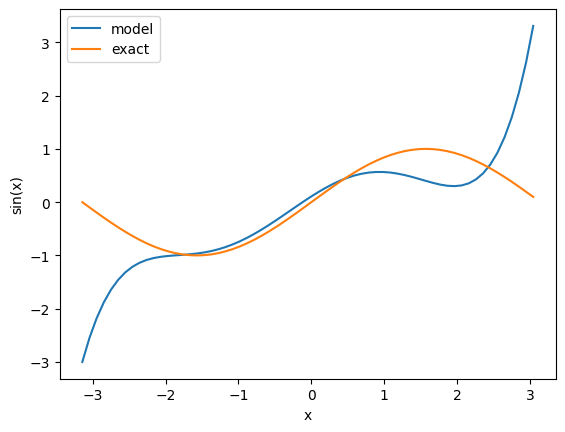

In [21]:
plot_model(model, proxy=proxy)

## Our remote accelerated training is complete. Let's go back to running on our own cluster.

In [22]:
available_resources.append((time.time(), int(my_alloc.nnodes)))
proxy.disable()

## Now that we've left the remote system, only our local resources are available again 

In [23]:
my_alloc = System()
print(f"# nodes available to me: {my_alloc.nnodes}", flush=True)
available_resources.append((time.time(), int(my_alloc.nnodes)))

# nodes available to me: 1


## Check our new model weights

In [24]:
print(f' Original Weights: {original_model.data} \n Updated Weights:  {model.fc.weight.data} ', flush=True)

 Original Weights: tensor([[ 0.0074,  0.9425, -0.1533, -0.1550,  0.1268,  0.1311]]) 
 Updated Weights:  tensor([[ 0.0930,  0.8759, -0.2263, -0.2475,  0.0276,  0.0277]]) 


## Check the error on our value of interest

In [25]:
parallel_exec_infer_approx(model, x)

model: 0.8015853762626648


## Cross-site Elasticity

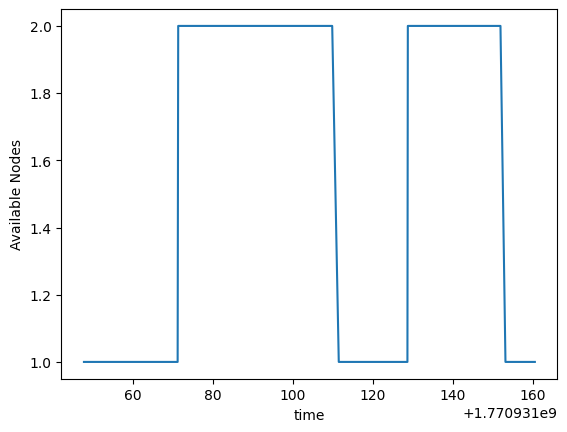

In [26]:
available_resources.append((time.time(), int(my_alloc.nnodes)))
plt.plot(*zip(*available_resources))
plt.xlabel('time')
plt.ylabel('Available Nodes')
plt.show()

In [27]:
proxy.enable()
cleanup(proxy)
proxy.disable()